In [1]:
import os
import numpy as np
import cv2
import tensorflow as tf 
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
IMG_SIZE = 128

image_dir = r"F:\work\python\archive\sample segmentation\images"
mask_dir = r"F:\work\python\archive\sample segmentation\masks"

In [3]:
images = []
masks = []

image_files = sorted(os.listdir(image_dir))
mask_files = sorted(os.listdir(mask_dir))

for img_file, mask_file in zip(image_files, mask_files):
    img = cv2.imread(os.path.join(image_dir, img_file))
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    mask = cv2.imread(os.path.join(mask_dir, mask_file), 0)
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))

    images.append(img)
    masks.append(mask)

images = np.array(images, dtype=np.float32) / 255.0
masks = np.array(masks, dtype=np.float32) / 255.0
masks = np.expand_dims(masks, axis=-1)

print("Images:", images.shape)
print("Masks:", masks.shape)
print("Mask values:", np.unique(masks))


Images: (1500, 128, 128, 3)
Masks: (1500, 128, 128, 1)
Mask values: [0.        0.2509804 0.5019608 0.7490196 1.       ]


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    images, masks, test_size=0.2, random_state=42
)

In [5]:
# 
def dice_loss(y_true, y_pred):
    smooth = 1e-6
    intersection = tf.reduce_sum(y_true * y_pred)
    return 1 - (2.*intersection + smooth) / (
        tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth
    )

def focal_loss(y_true, y_pred):
    gamma = 2.0
    alpha = 0.25
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    pt = tf.exp(-bce)
    return alpha * (1-pt)**gamma * bce

def combined_loss(y_true, y_pred):
    return dice_loss(y_true, y_pred) + focal_loss(y_true, y_pred)


In [6]:
def dice_coef(y_true, y_pred):
    smooth = 1e-6
    y_pred = tf.cast(y_pred > 0.5, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred)
    return (2.*intersection + smooth) / (
        tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth
    )

def iou_metric(y_true, y_pred):
    smooth = 1e-6
    y_pred = tf.cast(y_pred > 0.5, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection
    return (intersection + smooth) / (union + smooth)

In [7]:
def conv_block(x, filters):
    x = Conv2D(filters, 3, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    x = Conv2D(filters, 3, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    return x

In [8]:
def swin_block(x, num_heads=4):
    h, w, c = x.shape[1], x.shape[2], x.shape[3]

    x_flat = Reshape((h*w, c))(x)

    attn = MultiHeadAttention(
        num_heads=num_heads,
        key_dim=c//num_heads
    )(x_flat, x_flat)

    x = Add()([x_flat, attn])
    x = LayerNormalization()(x)

    x = Dense(c, activation="relu")(x)
    x = Dense(c)(x)

    x = Reshape((h, w, c))(x)
    return x

In [12]:
def attention_gate(x, g, filters):

    # Resize g to match x
    g = UpSampling2D(size=(
        x.shape[1] // g.shape[1],
        x.shape[2] // g.shape[2]
    ))(g)

    theta_x = Conv2D(filters, 1)(x)
    phi_g = Conv2D(filters, 1)(g)

    add = Add()([theta_x, phi_g])
    act = Activation("relu")(add)

    psi = Conv2D(1, 1, activation="sigmoid")(act)

    return Multiply()([x, psi])

In [18]:
def nested_decoder_block(x, skips, filters):

    up = UpSampling2D((2,2))(x)

    resized_skips = []

    for s in skips:
        # Resize using UpSampling instead of tf.image.resize
        while s.shape[1] < up.shape[1]:
            s = UpSampling2D((2,2))(s)

        resized_skips.append(s)

    x = Concatenate()([up] + resized_skips)
    x = conv_block(x, filters)

    return x

In [19]:
def build_model():
    inputs = Input((IMG_SIZE, IMG_SIZE, 3))

    # Encoder
    c1 = conv_block(inputs, 64)
    p1 = MaxPooling2D()(c1)

    c2 = conv_block(p1, 128)
    p2 = MaxPooling2D()(c2)

    c3 = conv_block(p2, 256)
    p3 = MaxPooling2D()(c3)

    c4 = conv_block(p3, 512)
    p4 = MaxPooling2D()(c4)

    # Bottleneck + Swin
    b1 = conv_block(p4, 1024)
    b1 = swin_block(b1)

    # Decoder (U-Net++)
    d4 = nested_decoder_block(b1, [c4], 512)
    d4 = attention_gate(d4, b1, 512)

    d3 = nested_decoder_block(d4, [c3, c4], 256)
    d3 = attention_gate(d3, d4, 256)

    d2 = nested_decoder_block(d3, [c2, c3], 128)
    d2 = attention_gate(d2, d3, 128)

    d1 = nested_decoder_block(d2, [c1, c2], 64)
    d1 = attention_gate(d1, d2, 64)

    outputs = Conv2D(1, 1, activation="sigmoid")(d1)

    return Model(inputs, outputs)

model = build_model()

In [20]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=combined_loss,
    metrics=["accuracy", dice_coef, iou_metric]
)


In [21]:
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5, verbose=1),
    tf.keras.callbacks.ModelCheckpoint("best_model.h5", save_best_only=True)
]

In [24]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=5,
    batch_size=16,
    callbacks=callbacks
)


Epoch 1/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.9921 - dice_coef: 0.7810 - iou_metric: 0.6483 - loss: 0.5915

75/75 ━━━━━━━━━━━━━━━━━━━━ 617s 8s/step - accuracy: 0.9928 - dice_coef: 0.8030 - iou_metric: 0.6764 - loss: 0.5687 - val_accuracy: 0.9856 - val_dice_coef: 0.1124 - val_iou_metric: 0.0628 - val_loss: 0.9519 - learning_rate: 1.0000e-04
Epoch 2/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.9941 - dice_coef: 0.8309 - iou_metric: 0.7139 - loss: 0.5261

75/75 ━━━━━━━━━━━━━━━━━━━━ 621s 8s/step - accuracy: 0.9941 - dice_coef: 0.8346 - iou_metric: 0.7198 - loss: 0.5062 - val_accuracy: 0.9896 - val_dice_coef: 0.6426 - val_iou_metric: 0.4796 - val_loss: 0.6591 - learning_rate: 1.0000e-04
Epoch 3/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9950 - dice_coef: 0.8556 - iou_metric: 0.7491 - loss: 0.4650

75/75 ━━━━━━━━━━━━━━━━━━━━ 541s 7s/step - accuracy: 0.9951 - dice_coef: 0.8625 - iou_metric: 0.7597 - loss: 0.4428 - val_accuracy: 0.9861 - val_dice_coef: 0.6673 - val_iou_metric: 0.5056 - val_loss: 0.5587 - learning_rate: 1.0000e-04
Epoch 4/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9957 - dice_coef: 0.8815 - iou_metric: 0.7898 - loss: 0.3944

75/75 ━━━━━━━━━━━━━━━━━━━━ 590s 8s/step - accuracy: 0.9957 - dice_coef: 0.8781 - iou_metric: 0.7846 - loss: 0.3908 - val_accuracy: 0.9938 - val_dice_coef: 0.7999 - val_iou_metric: 0.6700 - val_loss: 0.4648 - learning_rate: 1.0000e-04
Epoch 5/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9957 - dice_coef: 0.8815 - iou_metric: 0.7897 - loss: 0.3516

75/75 ━━━━━━━━━━━━━━━━━━━━ 562s 7s/step - accuracy: 0.9958 - dice_coef: 0.8835 - iou_metric: 0.7930 - loss: 0.3457 - val_accuracy: 0.9915 - val_dice_coef: 0.7698 - val_iou_metric: 0.6288 - val_loss: 0.4207 - learning_rate: 1.0000e-04


In [25]:
print("\nFinal Results:")
print("Train Loss:", history.history['loss'][-1])
print("Train Accuracy:", history.history['accuracy'][-1])
print("Train Dice:", history.history['dice_coef'][-1])
print("Train IoU:", history.history['iou_metric'][-1])

print("\nValidation Results:")
print("Val Loss:", history.history['val_loss'][-1])
print("Val Accuracy:", history.history['val_accuracy'][-1])
print("Val Dice:", history.history['val_dice_coef'][-1])
print("Val IoU:", history.history['val_iou_metric'][-1])



Final Results:
Train Loss: 0.34567955136299133
Train Accuracy: 0.995829164981842
Train Dice: 0.8834695219993591
Train IoU: 0.7929900884628296

Validation Results:
Val Loss: 0.42068684101104736
Val Accuracy: 0.9914968013763428
Val Dice: 0.76981121301651
Val IoU: 0.6287602186203003


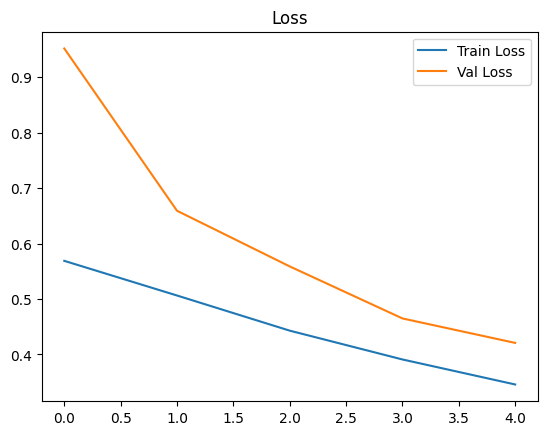

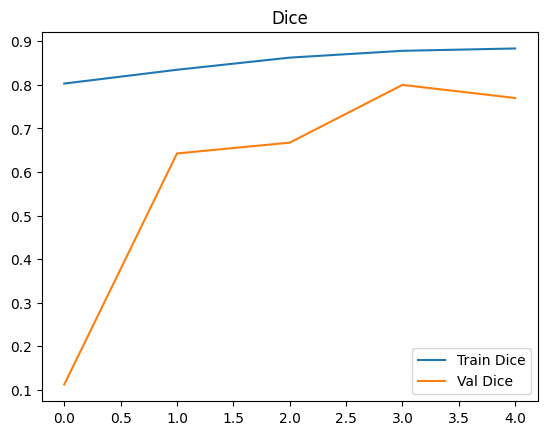

In [26]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend(); plt.title("Loss"); plt.show()

plt.plot(history.history['dice_coef'], label='Train Dice')
plt.plot(history.history['val_dice_coef'], label='Val Dice')
plt.legend(); plt.title("Dice"); plt.show()


In [27]:
preds = model.predict(X_test)
preds = (preds > 0.5).astype(np.uint8)

10/10 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step


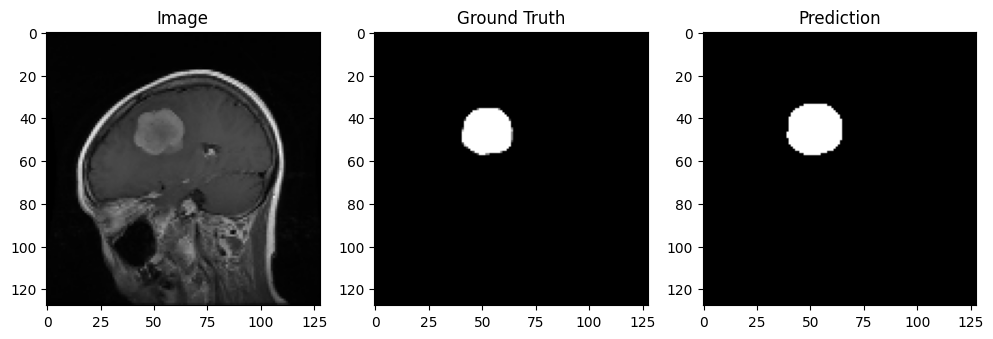

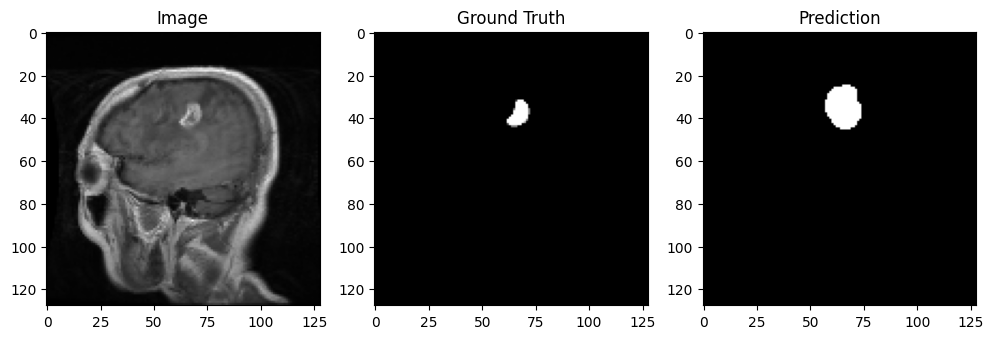

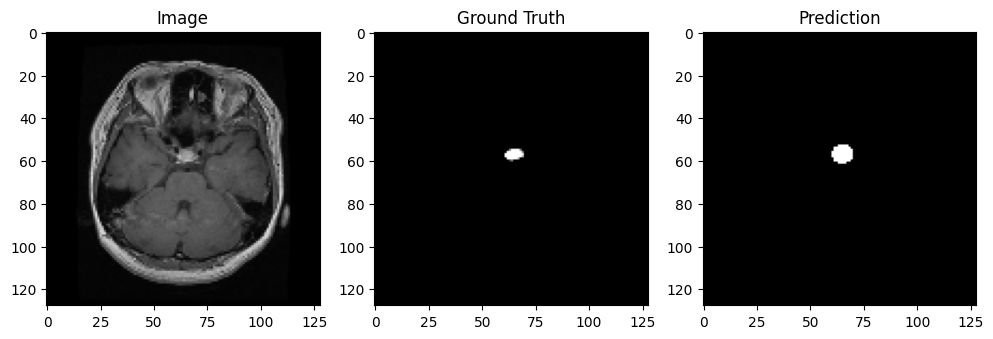

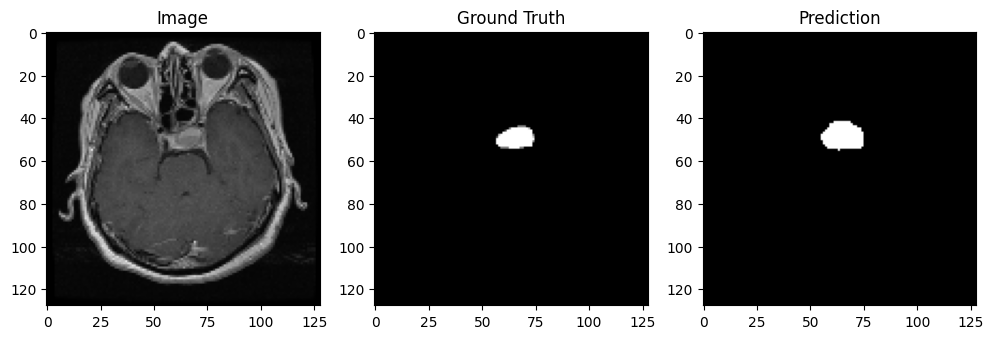

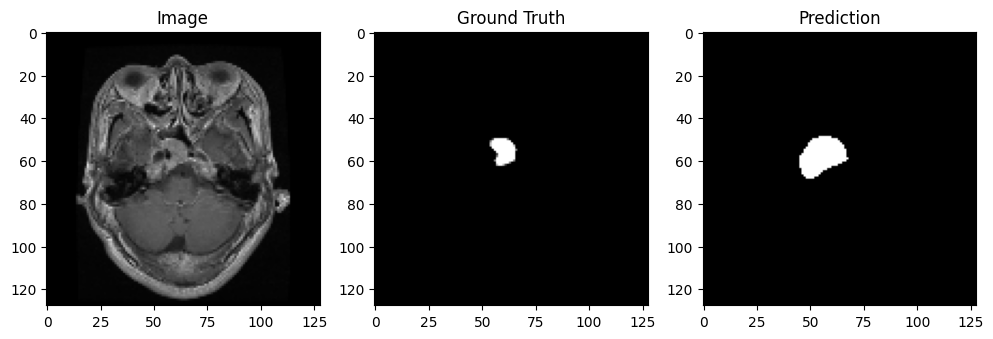

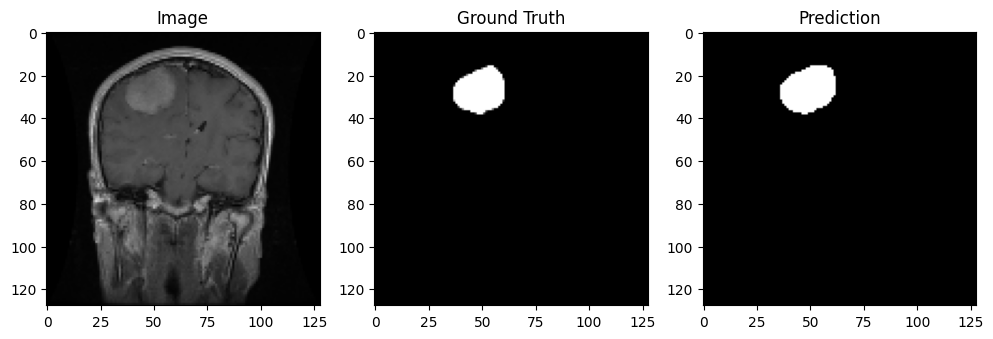

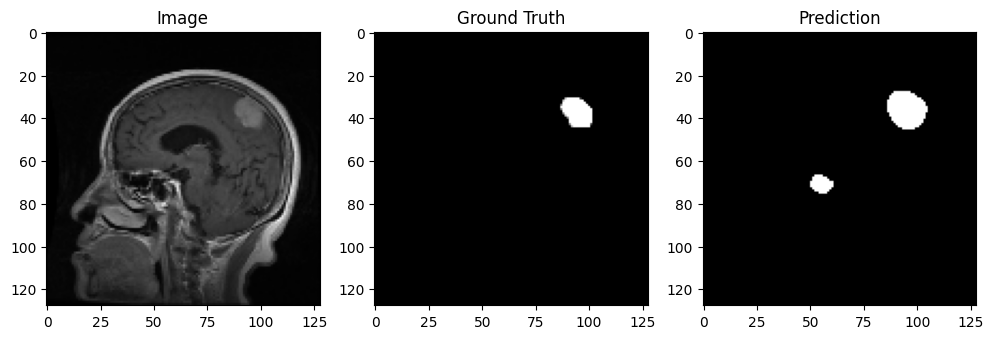

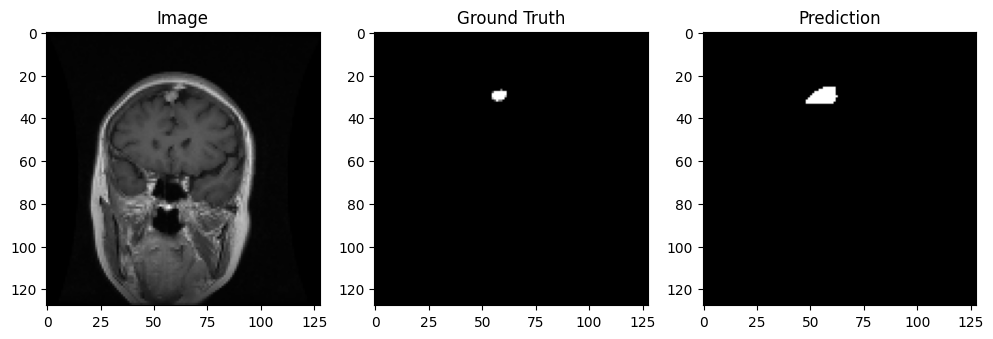

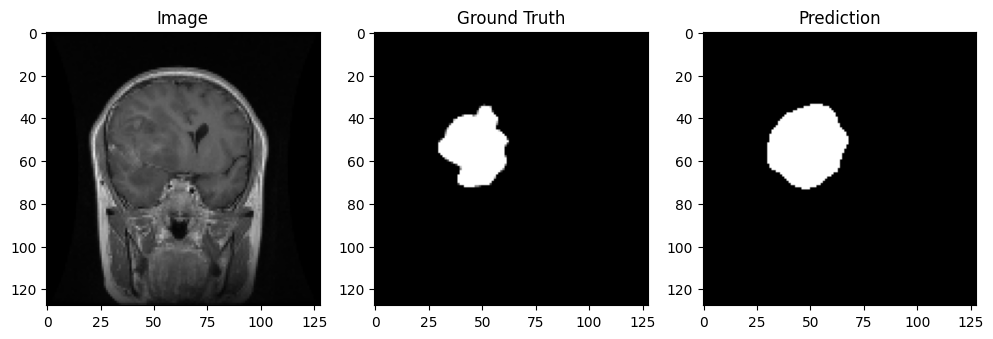

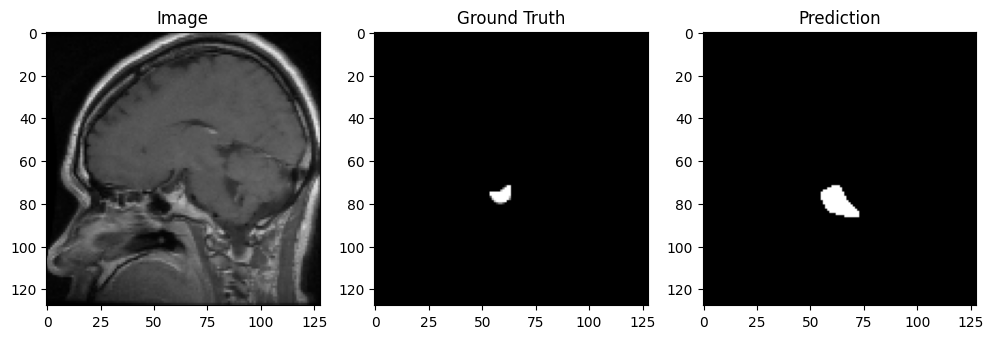

In [29]:
def show(i):
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(X_test[i])
    plt.title("Image")

    plt.subplot(1,3,2)
    plt.imshow(y_test[i].squeeze(), cmap='gray')
    plt.title("Ground Truth")

    plt.subplot(1,3,3)
    plt.imshow(preds[i].squeeze(), cmap='gray')
    plt.title("Prediction")

    plt.show()

for i in range(10):
    show(i)